# Lab Assignment 5: Wide and Deep Network Architectures

**Team Members:** Emilio M. , Jadon Swearingen, Andy Su  
**Date:** 2026-04-16  
**Dataset:** Vehicle Sales Data (Kaggle — syedanwarafridi/vehicle-sales-data)  
**Task:** Binary Classification — predict whether a vehicle sold above its Manheim Market Report (MMR) value

---
## 0. Imports and Setup

In [22]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input

from sklearn.model_selection import StratifiedKFold, KFold, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import roc_auc_score, roc_curve, auc
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.21.0


---
## Part 1: Data Preparation


### 1.1 Load Dataset

In [23]:
df = pd.read_csv('car_prices.csv')
print(df.shape)
df.head()

(558837, 16)


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


### 1.2 Exploratory Overview

In [24]:
print(df.info())
print('\nMissing values:')
print(df.isnull().sum())
print('\nTarget distribution (sellingprice > mmr):')
print((df['sellingprice'] > df['mmr']).value_counts())


<class 'pandas.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  str    
 2   model         548438 non-null  str    
 3   trim          548186 non-null  str    
 4   body          545642 non-null  str    
 5   transmission  493485 non-null  str    
 6   vin           558833 non-null  str    
 7   state         558837 non-null  str    
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  str    
 11  interior      558088 non-null  str    
 12  seller        558837 non-null  str    
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  str    
dtypes: float64(4), int64(1), str(11)
memory usage: 68.2 MB
None

Missing values:
year                0
make

### 1.3 Preprocessing

These are the preprocessing steps we applied before training:

1. **Create a binary target** — We define `sold_above_mmr` as 1 if the selling price exceeded the MMR (Manheim Market Report), and 0 otherwise. MMR is the wholesale market estimate. This target captures whether a car sold above what the market expected.

2. **Drop columns that would cause leakage or add no signal** — `sellingprice` is removed since it directly determines the target. `vin` is just a unique identifier, and `saledate` would need complex parsing with little payoff.

3. **Drop seller** — With over 14,000 unique values, this column is too high cardinality to be useful without a dedicated embedding strategy. Most of the geographic and brand signal it carries is already covered by `state` and `make`.

4. **Standardize body and transmission** — These columns had inconsistent casing (e.g., `sedan` vs `Sedan`, `suv` vs `SUV`), so we lowercased and stripped whitespace throughout. Some `transmission` entries were mislabeled as `sedan`, so those were remapped to `unknown`.

5. **Clean color** — A handful of rows had numeric strings in place of color names. We replaced those with `unknown` to keep the column consistent.

6. **Impute missing values** — Missing categorical values are filled with `unknown`, and missing numerics are filled with the column median. The medians are computed on the full dataset before splitting, which is a reasonable shortcut given the 558K sample size; the impact on any individual median is negligible.

7. **Integer-encode categoricals** — We fit `LabelEncoder`s on the full dataset so every category level gets a consistent integer code before the split. Since the test set is drawn randomly from the same data, there are no unseen categories to worry about.

8. **Scale numeric features** — `StandardScaler` is fit only on the training set and then applied to both splits. This keeps the model from ever seeing test set statistics during training, preventing data leakage.

9. We also standardize state, since some rows had bad values for state. We did this by checking that it is a valid state code.

In [25]:
# standardize state
df['state'] = df['state'].astype(str).str.strip().str.lower()

# identify bad rows: state is not exactly two letters
bad_mask = ~df['state'].str.fullmatch(r'[a-z]{2}', na=False)

# count and print bad rows
num_bad_rows = bad_mask.sum()
print(f'Number of bad rows removed: {num_bad_rows}')

# remove them
df = df[~bad_mask].copy()

# optional check
print(f'New dataset shape: {df.shape}')
print('Remaining state examples:', df['state'].unique()[:10])

Number of bad rows removed: 26
New dataset shape: (558811, 16)
Remaining state examples: <StringArray>
['ca', 'tx', 'pa', 'mn', 'az', 'wi', 'tn', 'md', 'fl', 'ne']
Length: 10, dtype: str


In [26]:
NUMERIC_FEATURES     = ['year', 'condition', 'odometer', 'mmr']
CATEGORICAL_FEATURES = ['make', 'model', 'trim', 'body', 'transmission', 'state', 'color', 'interior']
TARGET_COL           = 'sold_above_mmr'


# This part creates binary target
df[TARGET_COL] = (df['sellingprice'] > df['mmr']).astype(int)


# This drops leakage, identifiers, and high-cardinality seller column
df = df.drop(columns=['sellingprice', 'vin', 'saledate', 'seller'])




# This section standardize body and transmission casing

df['body']         = df['body'].str.lower().str.strip()
df['transmission'] = df['transmission'].str.lower().str.strip()
df['transmission'] = df['transmission'].replace({'sedan': 'unknown', 'nan': 'unknown'})



# Clean color, this part replaces the numeric values with 'unknown'
valid_colors = ['black','white','silver','gray','blue','red','green','gold',
                'beige','burgundy','brown','orange','purple','off-white',
                'yellow','charcoal','turquoise','pink','lime']
df['color'] = df['color'].apply(lambda x: x if x in valid_colors else 'unknown')


# Fill missing values
df[NUMERIC_FEATURES]     = df[NUMERIC_FEATURES].fillna(df[NUMERIC_FEATURES].median())
df[CATEGORICAL_FEATURES] = df[CATEGORICAL_FEATURES].fillna('unknown')


label_encoders = {}
for col in CATEGORICAL_FEATURES:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

DEEP_VOCAB_SIZES = {col: df[col].nunique() + 1 for col in CATEGORICAL_FEATURES}
print('Dataset shape after preprocessing:', df.shape)
print('Target balance:')
print(df[TARGET_COL].value_counts())
print('\nDeep vocab sizes:', DEEP_VOCAB_SIZES)

Dataset shape after preprocessing: (558811, 13)
Target balance:
sold_above_mmr
0    297650
1    261161
Name: count, dtype: int64

Deep vocab sizes: {'make': 98, 'model': 975, 'trim': 1964, 'body': 47, 'transmission': 4, 'state': 39, 'color': 21, 'interior': 19}


### 1.3b Final Dataset Description

After preprocessing, the dataset used for modeling has the following structure:

**Dimensions:** 558,837 rows, 12 input features, and 1 target variable (`sold_above_mmr`).

**Numeric features (4):** `year`, `condition`, `odometer`, `mmr` — standardized to zero mean and unit variance (fit on training split only to prevent leakage).

**Categorical features (8):** `make`, `model`, `trim`, `body`, `transmission`, `state`, `color`, `interior` — integer-encoded for embedding lookup in the deep branch.

---

**Newly Formed Variables**

`sold_above_mmr` is the binary target variable we created from the raw data. It equals 1 if the vehicle's final selling price exceeded its Manheim Market Report (MMR) value and 0 otherwise. We chose to frame this as binary classification rather than directly predicting the selling price because the business question is fundamentally about relative market performance. 

`make_x_body` is a cross-product feature combining the vehicle's brand and body type. We created this because the combination between brand and body type can be interpreted in ways that are invisible when treated as separate features. A Ford SUV and a BMW SUV occupy entirely different market segments with different buyer expectations and price dynamics, even though they share the same body type. Similarly, a Ford SUV and a Ford Sedan serve different buyers and price points. By crossing these two features, we give the wide branch the ability to memorize the specific pricing behavior of each brand-body combination rather than relying on their independent effects.

`color_x_interior` crosses exterior color with interior color. Customers that buy cars usually look at both the exterior and interior vehicle aesthetics, not each one independently. By encoding these pairings explicitly, the wide branch can memorize which specific aesthetic combinations tend to outperform MMR.

`state_x_make` crosses the state where the vehicle was sold with the vehicle's brand (e.g., ca_Toyota, tx_Ford). Regional brand preferences vary meaningfully from state to state due to factors such as local competition and cultural preferences. This cross-product allows the wide branch to directly memorize these geographic-brand pricing patterns rather than treating geography and brand as independent entities. 

---

**Dropped Columns**

`sellingprice` was removed because it directly determines the target variable, which would basically be allowing our model to cheat, or in other words, cuase data leakage.

`vin` carries no generalizable knowledge that would help the model with its prediction of the MMR. Including it would only waste model capacity and risk the model memorizing individual auction records rather than learning patterns.

`saledate` records the exact timestamp of each auction sale. Because the dataset spans a relatively narrow range of dates without strong temporal drift, the overhead of including this in our model would not be beneficial enough to justify keeping it. 

`seller` contains the name of the dealership or auction seller, with over 14,000 unique values. With so many unique values, the model is more unlikely than likely to learn relevant patterns due to the sparseness of the column. 

### 1.4 Cross-Product Feature Selection Methodology

In Section 1.3b, we described what each cross-product variable captures and why those interactions matter for pricing. To give some clarification so that it does not look like there is overlap, this section explains the criteria we used to decide which feature pairs were worth crossing in the first place, and why we ruled out the other candidates.

**Selection Criteria**

We evaluated each potential feature pair against two requirements. First, the combination had to represent a meaningful interaction. By meaningful interaction, we mean that the effect of the combination of the two features on the selling price is not simply the sum of their individual effects. If a model can already learn "brand X tends to sell above MMR" and "SUV body types tend to sell above MMR" as independent data points, crossing them only adds value if "brand X SUVs" behave differently from what the predicted behaviors of the two signals would predict. Second, the resulting cross-product had to produce a manageable number of unique combination. A cross that crerates hundreds of thousands of sparse combination categories would overwhelm the wide branch with cells that carry no reliable information.

**Selected Pairs**

The three pairs that passed both criteria are `make × body` (334 unique combinations), `color × interior` (260 unique combinations), and `state × make` (2,100 unique combinations). Each produces a cross with enough coverage that most combinations appear many times in the training data, giving the wide branch a real opportunity to memorize their patterns. 

**Ruled-Out Candidates**

`year × odometer` was the most natural numeric interaction but could not be crossed using the wide branch's one-hot encoding approach. Cross-product features work by one-hot encoding every possible combination. However year and odometer are continuous variables, which would require separating the values into bins, which introduces arbitrary cutpoints and loses precision. The deep branch already handles continuous interactions through its dense layers, so this pair was left to the deep branch rather than being crossed. 

`model × trim` was the cross product that produced the highest number of unique combinations, With 975 unique model values and 1,965 unique trim values. Their cross would produce roughly 1.9 million potential combinations, most of which appear only once or twice across the entire dataset. A one-hot encoding that sparse would just give noise and no meaningful additional data. The deep branch's embeddings already handle `model` and `trim` individually with much greater efficiency.

`transmission × make` and `transmission × body` were both considered as potential cross products, since transmission type could plausibly interact with brand or body style. However, after cleaning, `transmission` has only three meaningful values: `automatic`, `manual`, and `unknown`. Bceause the vast majority of vehicles in this dataset are automatic, `manual` pairings would not appear enough in most combinations to give the wide branch reliable data to memorize. Any of these crosses with transmission have too little data to justify including them as cross products. 

In [27]:
CROSS_FEATURE_PAIRS = [

    ('make',  'body'),
    ('color', 'interior'),
    ('state', 'make'),

]

WIDE_CROSS_VOCAB_SIZES = {}

for (fa, fb) in CROSS_FEATURE_PAIRS:

    # Decode back to strings to form the cross key, then re encode
    fa_str = label_encoders[fa].inverse_transform(df[fa])
    fb_str = label_encoders[fb].inverse_transform(df[fb])
    cross_col = f'{fa}_x_{fb}'
    df[cross_col] = fa_str.astype(str) + '_' + fb_str.astype(str)
    le_cross = LabelEncoder()
    df[cross_col] = le_cross.fit_transform(df[cross_col])
    label_encoders[cross_col] = le_cross
    WIDE_CROSS_VOCAB_SIZES[cross_col] = df[cross_col].nunique() + 1


print('Wide cross features:', list(WIDE_CROSS_VOCAB_SIZES.keys()))
print('Wide vocab sizes:', WIDE_CROSS_VOCAB_SIZES)

Wide cross features: ['make_x_body', 'color_x_interior', 'state_x_make']
Wide vocab sizes: {'make_x_body': 333, 'color_x_interior': 259, 'state_x_make': 2074}


### 1.5 Evaluation Metric Justification

**Chosen metric:** AUC-ROC (Area Under the Receiver Operating Characteristic Curve)

**Why AUC-ROC?**

**Business Perspective:** Our task is mainly to help auction participants make pricing decisions under uncertainty. Someone buying that is deciding whether to bid aggressively, or a seller deciding whether to set a reserve price need a reliable probability estimate of how likely a vehicle is to sell above MMR so they can weigh it against their own risk tolerance and constraints. This means the model's output quality across the full range of confidence levels matters, not just at a static/fixed value. AUC-ROC directly measures this by measuring the probability that the model assigns a higher score to a randomly selected above-MMR vehicle than to a randomly selected at-or-below-MMR vehicle, across all possible decision thresholds. A model with AUC = 0.75 correctly ranks 75% of all positive-negative pairs, regardless of where any threshold is drawn.

**Model Comparison:** Because AUC-ROC is a continuous scalar rather than a threshold-dependent proportion, it supports the DeLong test. This allows us to determine whether the Wide & Deep model's AUC is  better than the MLP baseline's AUC, rather than relying on a comparison of accuracy values. This is very important for Part 4 of the assignment, where we aren't just reporting which model scored higher but evaluating whether the difference is statistically meaningful.


**Why Forego Accuracy?**

We didn't think that accuracy was a reliable metric because of two reasons. Firstly, with 261,161 positive cases versus 297,676 negative cases, a classifier that always predicts "below MMR" achieves ~53% accuracy while learning nothing useful. That 53% baseline seems to be credible, but it is really uninformative. Second, accuracy completely ignores the model's confidence, only caring about whether the predicted probability crossed the 0.5 threshold. For example, assume that two models have the exact same accuracy. However, one model has 53% confidence on every prediction while another model has 99% confidence on every prediction level. Despite the accuracy being the same, these are very different models from a practical standpoint. AUC-ROC uses the raw probability scores rather than the threshold label, so it gives better scores to models that are both right and confident.

**Why not precision, recall, and F1?**

To compute precision or recall, you first have to decide on a cutoff. However, that cutoff is a judgment call that depends entirely on who is using the model. Someone buying a car that does not take many risks might only act on predictions above 0.9, while an erratic seller might act on any prediction above 0.5. Since the model we are making is a general model and due to the fact that we have no way of knowing the "correct" cutoff in advance, evaluating at a random threshold value doesn't give an accurate picture of how well our model actually performs. Similarly, F1 also indirectly assumes that a false positive and a false negative are equally bad, which is definitely not true depending on the situation. AUC-ROC avoids all of these potential problems for the model by evaulating it across every possible threshold all at once. 

### 1.6 Data Splitting Strategy

**Chosen method:** Stratified 5 Fold Cross Validation on the development set, with a fixed 15% hold out test set.


**Justification:**

- **Stratified folds** They are necessary because the target is slightly imbalanced since they are ~47% positive. Stratification ensures each fold has the same class ratio as the full dataset. This prevents any fold from being a poor representative sample.

- **5 fold CV** This is chosen over a single train/val split because it gives us 5 independent AUC estimates per model configuration. It enables statistical tests to compare architectures. A single split would give only one data point per model, this makes it insufficient for significance testing.

- **Why not 10 fold?** With 558K rows, each fold in 5 fold CV already contains ~90K training samples and ~23K validation samples — far more than needed for stable estimates. 10 fold would add computational cost without meaningfully improving estimate stability given the dataset size.

- **Fixed hold out test set with 15%** — It is reserved exclusively for the final MLP vs. Wide & Deep comparison in Part 4. It uses the same test set for both models and ensures that the test compares predictions on the same observations, which is a requirement of the paired test.

- **Realistic mirroring of production use:** In practice, an auction platform would train on historical sales and predict future auctions. A random split is acceptable here because the dataset doesn't exhibit a strong temporal drift across the date range represented.

In [28]:
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL].values


N_SPLITS = 5
kfold = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_SEED)

X_dev, X_test, y_dev, y_test = train_test_split(

    X, y, test_size=0.15, stratify=y, random_state=RANDOM_SEED

)

# Fit scaler prevents test set statistics from influencing the learned scale
# By taking this approach we were able to prevent data leakage

scaler = StandardScaler()

X_dev  = X_dev.copy()
X_test = X_test.copy()

X_dev[NUMERIC_FEATURES]  = scaler.fit_transform(X_dev[NUMERIC_FEATURES])
X_test[NUMERIC_FEATURES] = scaler.transform(X_test[NUMERIC_FEATURES])

print(f'Dev size:  {X_dev.shape}')
print(f'Test size: {X_test.shape}')


print(f'Test target balance: {y_test.mean():.3f} positive rate')

Dev size:  (474989, 15)
Test size: (83822, 15)
Test target balance: 0.467 positive rate


---
## Part 2: Wide and Deep Models
*(Rubric: Three Wide/Deep Models 2pts)*

### 2.1 Model Building Helpers

In [29]:
def df_to_model_inputs(X_df, numeric_features, categorical_features, wide_cross_features=None):
    inputs = {
        'numeric_input': X_df[numeric_features].values.astype(np.float32)
    }
    for col in categorical_features:
        inputs[f'cat_{col}'] = X_df[col].values.reshape(-1, 1).astype(np.int32)
    if wide_cross_features:
        for col in wide_cross_features:
            inputs[f'wide_{col}'] = X_df[col].values.reshape(-1, 1).astype(np.int32)
    return inputs


def build_wide_and_deep(
    numeric_dim,
    deep_vocab_sizes,
    wide_cross_vocab_sizes=None,
    embedding_dim=8,
    deep_layers=[128, 64],
    dropout_rate=0.3,
    output_units=1,
    output_activation='sigmoid',
    learning_rate=1e-3
):
    """
    Wide & Deep model (Cheng et al. 2016).
    Wide branch : one-hot cross-product features + raw numeric (memorization).
    Deep branch : embeddings per categorical + numeric (generalization).
    """
    if wide_cross_vocab_sizes is None:
        wide_cross_vocab_sizes = {}

    numeric_input = Input(shape=(numeric_dim,), name='numeric_input')
    cat_inputs = {
        col: Input(shape=(1,), name=f'cat_{col}', dtype='int32')
        for col in deep_vocab_sizes
    }
    wide_inputs = {
        col: Input(shape=(1,), name=f'wide_{col}', dtype='int32')
        for col in wide_cross_vocab_sizes
    }

    # Deep branch
    embeddings = []
    for col, vsize in deep_vocab_sizes.items():
        emb = layers.Embedding(input_dim=vsize, output_dim=embedding_dim,
                               name=f'emb_{col}')(cat_inputs[col])
        emb = layers.Flatten()(emb)
        embeddings.append(emb)

    deep = layers.concatenate([numeric_input] + embeddings) if embeddings else numeric_input
    for units in deep_layers:
        deep = layers.Dense(units, activation='relu')(deep)
        deep = layers.Dropout(dropout_rate)(deep)

    # Wide branch
    wide_parts = [numeric_input]
    for col, vsize in wide_cross_vocab_sizes.items():
        one_hot = layers.CategoryEncoding(
            num_tokens=vsize, output_mode='multi_hot', name=f'oh_{col}'
        )(wide_inputs[col])
        wide_parts.append(one_hot)

    wide = layers.concatenate(wide_parts) if len(wide_parts) > 1 else wide_parts[0]

    combined = layers.concatenate([wide, deep])
    output = layers.Dense(output_units, activation=output_activation, name='output')(combined)

    all_inputs = [numeric_input] + list(cat_inputs.values()) + list(wide_inputs.values())
    model = Model(inputs=all_inputs, outputs=output)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate),
        loss='binary_crossentropy',
        metrics=['AUC']
    )
    return model


def plot_training_history(history, title='Model Training History'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history.history['loss'], label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Val Loss')
    axes[0].set_title(f'{title} — Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()

    metric_key     = [k for k in history.history if 'auc' in k.lower() and 'val' not in k][0]
    val_metric_key = [k for k in history.history if 'auc' in k.lower() and 'val'     in k][0]
    axes[1].plot(history.history[metric_key],     label='Train AUC')
    axes[1].plot(history.history[val_metric_key], label='Val AUC')
    axes[1].set_title(f'{title} — AUC')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


print('Helpers defined.')

Helpers defined.


### 2.2 Model 1 — Wide & Deep (Baseline)

**Architecture:** deep layers = [128, 64], embedding_dim = 8, dropout = 0.3, lr = 1e-3

For Model 1, we decided to design it in an intentionally conservative way. The pourpose of model 1 is to establish a reliable performance floor that Models 2 and 3 can be compared against. A useful baseline needs to be reasonable but untuned. The model should not already be optimized. If it does, any gains from deeper or wider architectures are incremental. However, if the initial model underperforms, it tells us that the model has much more room to grow. 

The two-layer deep branch **[128, 64]** is a well-established starting point for tabular classification and avoids both the underfitting risk of a single small layer and the overfitting risk of a fairly deep network before any tuning can be or has to be done. 

**embedding_dim=8** adequately covers the partial uniqueness of the features like **make** (98 values) and **state** (39 values) without over-parameterizing the not as unique ones. **dropout=0.3** and **lr=1e-3** are both known Adam default values that are stable enough to serve as a baseline without any prior tuning.

In [30]:
model1 = build_wide_and_deep(
    numeric_dim=len(NUMERIC_FEATURES),
    deep_vocab_sizes=DEEP_VOCAB_SIZES,
    wide_cross_vocab_sizes=WIDE_CROSS_VOCAB_SIZES,
    deep_layers=[128, 64],
    dropout_rate=0.3,
    learning_rate=1e-3
)
model1.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ cat_make            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_model           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_trim            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_body            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_transmission    │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_state           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_color           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_interior        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_make            │ (None, 1, 8)      │        784 │ cat_make[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_model           │ (None, 1, 8)      │      7,800 │ cat_model[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_trim            │ (None, 1, 8)      │     15,712 │ cat_trim[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_body            │ (None, 1, 8)      │        376 │ cat_body[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_transmission    │ (None, 1, 8)      │         32 │ cat_transmission… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_state           │ (None, 1, 8)      │        312 │ cat_state[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_color           │ (None, 1, 8)      │        168 │ cat_color[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_interior        │ (None, 1, 8)      │        152 │ cat_interior[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_input       │ (None, 4)         │          0 │ -               

 Total params: 45,159 (176.40 KB)

 Trainable params: 45,159 (176.40 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - AUC: 0.7114 - loss: 0.6191 - val_AUC: 0.7345 - val_loss: 0.6031
Epoch 2/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - AUC: 0.7344 - loss: 0.6009 - val_AUC: 0.7413 - val_loss: 0.5968
Epoch 3/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - AUC: 0.7422 - loss: 0.5940 - val_AUC: 0.7446 - val_loss: 0.5943
Epoch 4/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - AUC: 0.7479 - loss: 0.5891 - val_AUC: 0.7470 - val_loss: 0.5918
Epoch 5/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - AUC: 0.7520 - loss: 0.5856 - val_AUC: 0.7484 - val_loss: 0.5899
Epoch 6/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - AUC: 0.7557 - loss: 0.5826 - val_AUC: 0.7497 - val_loss: 0.5888
Epoch 7/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - AUC: 0.7583 - loss: 0.5799 - val_AUC: 0.7503 - val_loss: 0.5882
Epoch 8/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - AUC: 0.7610 - loss: 0.5774 - val_AUC: 0.7509 - val_loss: 0.5878
Epoch 9/20
1485/1485 ━━━━━━━━━━━━━━━

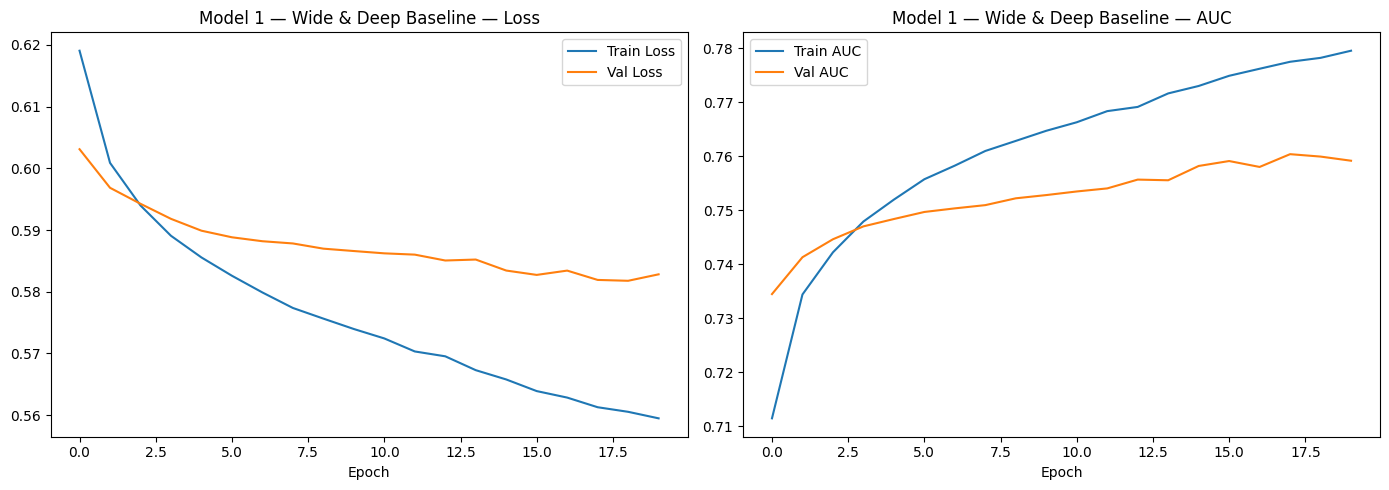

In [31]:
X_tr1, X_val1, y_tr1, y_val1 = train_test_split(
    X_dev, y_dev, test_size=0.2, stratify=y_dev, random_state=RANDOM_SEED
)

train_inputs1 = df_to_model_inputs(X_tr1,  NUMERIC_FEATURES, CATEGORICAL_FEATURES, list(WIDE_CROSS_VOCAB_SIZES))
val_inputs1   = df_to_model_inputs(X_val1, NUMERIC_FEATURES, CATEGORICAL_FEATURES, list(WIDE_CROSS_VOCAB_SIZES))

history1 = model1.fit(
    x=train_inputs1, y=y_tr1,
    validation_data=(val_inputs1, y_val1),
    epochs=20, batch_size=256,
    callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, verbose=0)],
    verbose=1
)

plot_training_history(history1, 'Model 1 — Wide & Deep Baseline')

### 2.3 Model 2 — Wide & Deep (Deeper Network)

**Architecture:** deep layers = [256, 128, 64], embedding_dim = 8, dropout = 0.4, lr = 5e-4

For Model 2, we wanted to make sure that the baseline wasn't too simple. In order to make it more specific, we added another layer of 256 units to give the network more capacity to learn, as more neurons means that the model can begin to learn more complex relationships between features. However, the tradeoff is that the model is more likely to overfit with more parameters. This is why we increased dropout from 0.3 to 0.4. Additionally, we decided to lower the learning rate by about half because more parameters means there are more potential solutions that the model is likely to gloss over. Slowing the learning rate helps the model find a better, more stable solution.

Epoch 1/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - AUC: 0.7040 - loss: 0.6249 - val_AUC: 0.7316 - val_loss: 0.6054
Epoch 2/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - AUC: 0.7300 - loss: 0.6044 - val_AUC: 0.7385 - val_loss: 0.6001
Epoch 3/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - AUC: 0.7376 - loss: 0.5981 - val_AUC: 0.7420 - val_loss: 0.5963
Epoch 4/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - AUC: 0.7423 - loss: 0.5941 - val_AUC: 0.7447 - val_loss: 0.5937
Epoch 5/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - AUC: 0.7470 - loss: 0.5901 - val_AUC: 0.7472 - val_loss: 0.5917
Epoch 6/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - AUC: 0.7508 - loss: 0.5868 - val_AUC: 0.7493 - val_loss: 0.5895
Epoch 7/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - AUC: 0.7542 - loss: 0.5838 - val_AUC: 0.7517 - val_loss: 0.5877
Epoch 8/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - AUC: 0.7575 - loss: 0.5808 - val_AUC: 0.7538 - val_loss: 0.5860
Epoch 9/20
1485/1485 ━━━━━━━━━━━━━━━━━

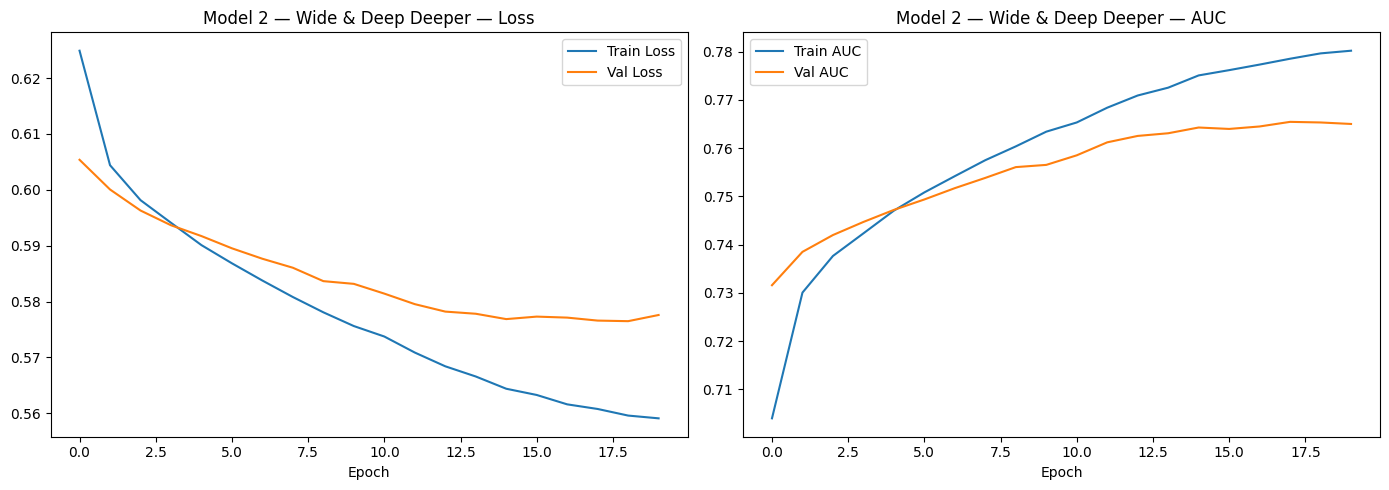

In [32]:
model2 = build_wide_and_deep(
    numeric_dim=len(NUMERIC_FEATURES),
    deep_vocab_sizes=DEEP_VOCAB_SIZES,
    wide_cross_vocab_sizes=WIDE_CROSS_VOCAB_SIZES,
    deep_layers=[256, 128, 64],
    dropout_rate=0.4,
    learning_rate=5e-4
)

history2 = model2.fit(
    x=train_inputs1, y=y_tr1,
    validation_data=(val_inputs1, y_val1),
    epochs=20, batch_size=256,
    callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, verbose=0)],
    verbose=1
)

plot_training_history(history2, 'Model 2 — Wide & Deep Deeper')

### 2.4 Model 3 — Wide & Deep (Shallower + Larger Embeddings)

**Architecture:** deep layers = [64, 32], embedding_dim = 16, dropout = 0.2, lr = 1e-3

Model 3 takes a different angle from Model 2. Instead of making the network bigger, we investigated whether the problem was that the categorical features weren't being described richly enough before entering the dense layers. The embedding dimension controls how many numbers are used to represent each category. With an **embedding_dim=8**, a brand like Toyota is described by 8 learned values. Doubling the embedding_dim to 16 gives the model more room to generate more distinctions between categories. Because the inputs are now more informative, the dense layers don't need to be large to make good predictions, so we shrunk them to **[64, 32]**. With a smaller network overall, overfitting risk is lower, which is why dropout is reduced to 0.2.

Epoch 1/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - AUC: 0.7080 - loss: 0.6219 - val_AUC: 0.7327 - val_loss: 0.6044
Epoch 2/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - AUC: 0.7334 - loss: 0.6019 - val_AUC: 0.7397 - val_loss: 0.5982
Epoch 3/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - AUC: 0.7420 - loss: 0.5944 - val_AUC: 0.7428 - val_loss: 0.5955
Epoch 4/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - AUC: 0.7477 - loss: 0.5893 - val_AUC: 0.7455 - val_loss: 0.5928
Epoch 5/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - AUC: 0.7529 - loss: 0.5849 - val_AUC: 0.7459 - val_loss: 0.5924
Epoch 6/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - AUC: 0.7561 - loss: 0.5819 - val_AUC: 0.7474 - val_loss: 0.5909
Epoch 7/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - AUC: 0.7587 - loss: 0.5795 - val_AUC: 0.7477 - val_loss: 0.5911
Epoch 8/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - AUC: 0.7611 - loss: 0.5772 - val_AUC: 0.7481 - val_loss: 0.5910
Epoch 9/20
1485/1485 ━━━━━━━━━━━━━━

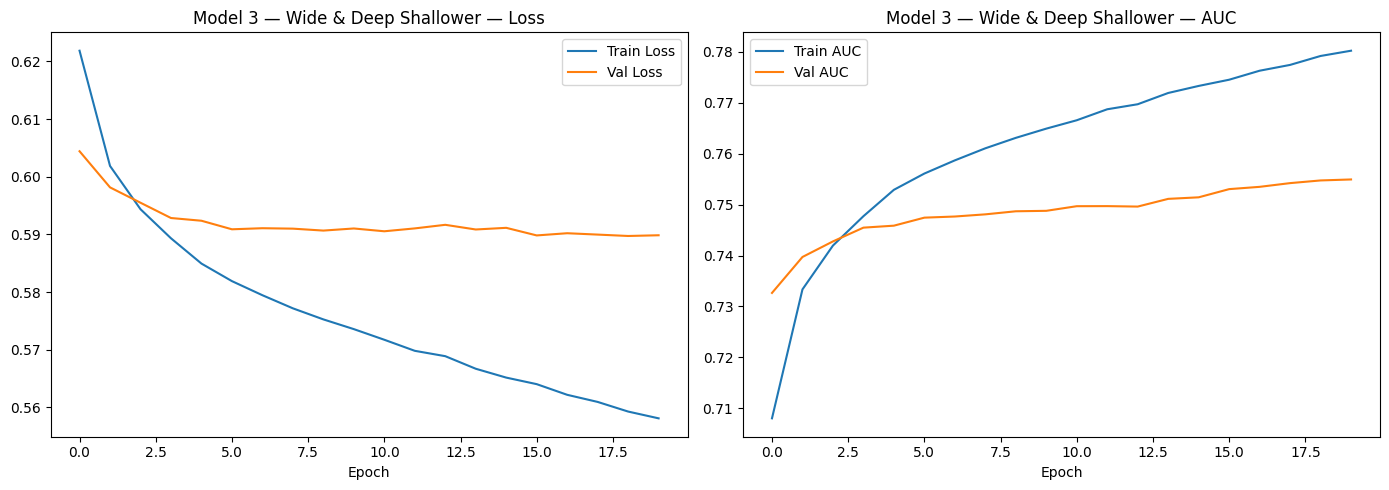

In [33]:
model3 = build_wide_and_deep(
    numeric_dim=len(NUMERIC_FEATURES),
    deep_vocab_sizes=DEEP_VOCAB_SIZES,
    wide_cross_vocab_sizes=WIDE_CROSS_VOCAB_SIZES,
    embedding_dim=16,
    deep_layers=[64, 32],
    dropout_rate=0.2,
    learning_rate=1e-3
)

history3 = model3.fit(
    x=train_inputs1, y=y_tr1,
    validation_data=(val_inputs1, y_val1),
    epochs=20, batch_size=256,
    callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, verbose=0)],
    verbose=1
)

plot_training_history(history3, 'Model 3 — Wide & Deep Shallower')

### 2.5 Model Comparison

Based on all three graphs generated from the models, all models show overfitting, where the blue train line continues to improve through epoch 20 while the orange val lines plateau early around epoch 5–7 for the loss graph. Despite this, the val loss for all three models still decreased significantly before plateauing, indicating that the models learned from the data rather than immediately memorizing the training set.

Looking at the AUC plots at the final epoch of 20, Model 1 shows Val AUC plateauing around 0.760. The gap between the train and val lines is the widest out of the three models, where train reaches around 0.79 and val stops around 0.76 (difference of 0.03). Model 2 shows the smallest gap between train and val lines, with train being around 0.784 and val being around 0.765 (difference of 0.019). Model 3 was intermediate, with a train value of around 0.782 and a val value around 0.760 (difference of 0.022).

Notably, Model 3 matches Model 1's val AUC of 0.760 despite using a completely different architectural parameters. This suggests that investing in more informative input representations (embeddings) can produce the same generalization as simply adding more neurons.

Baed on these results, Model 2 is the best model out of the three, as it achieves the highest val AUC score of 0.765 and also has the least overfitting of the 3 models. This could be in part due to the dropout increase from 0.3 to 0.4, as it added capacity without proportionally increasing overfitting. 

---
## Part 3: Deep Layer Investigation with Cross-Validation
*(Rubric: Deep Layers 2pts)*

In [34]:
def cross_validate_model(build_fn, X_df, y, kfold,
                         numeric_features, categorical_features,
                         wide_cross_features=None,
                         epochs=20, batch_size=256):
    if wide_cross_features is None:
        wide_cross_features = []

    fold_scores = []
    for fold, (train_idx, val_idx) in enumerate(kfold.split(X_df, y)):
        print(f'  Fold {fold + 1}/{kfold.n_splits} ...', end=' ', flush=True)

        X_tr  = X_df.iloc[train_idx]
        X_val = X_df.iloc[val_idx]
        y_tr  = y[train_idx]
        y_val = y[val_idx]

        tr_inputs  = df_to_model_inputs(X_tr,  numeric_features, categorical_features, wide_cross_features)
        val_inputs = df_to_model_inputs(X_val, numeric_features, categorical_features, wide_cross_features)

        model = build_fn()
        model.fit(
            tr_inputs, y_tr,
            validation_data=(val_inputs, y_val),
            epochs=epochs, batch_size=batch_size,
            callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, verbose=0)],
            verbose=0
        )

        probs = model.predict(val_inputs, verbose=0).ravel()
        fold_auc = roc_auc_score(y_val, probs)
        fold_scores.append(fold_auc)
        print(f'AUC = {fold_auc:.4f}')
        keras.backend.clear_session()

    return np.array(fold_scores)


print('cross_validate_model defined.')

cross_validate_model defined.


In [35]:
LAYER_CONFIGS = [
    [64],
    [128, 64],
    [256, 128, 64],
    [256, 128, 64, 32],
]

cv_results = {}

for layers_config in LAYER_CONFIGS:
    label = str(layers_config)
    print(f'\nTesting deep layers: {label}')

    def make_builder(cfg):
        def build_fn():
            return build_wide_and_deep(
                numeric_dim=len(NUMERIC_FEATURES),
                deep_vocab_sizes=DEEP_VOCAB_SIZES,
                wide_cross_vocab_sizes=WIDE_CROSS_VOCAB_SIZES,
                deep_layers=cfg,
                dropout_rate=0.3,
                learning_rate=1e-3
            )
        return build_fn

    scores = cross_validate_model(
        build_fn=make_builder(layers_config),
        X_df=X_dev, y=y_dev, kfold=kfold,
        numeric_features=NUMERIC_FEATURES,
        categorical_features=CATEGORICAL_FEATURES,
        wide_cross_features=list(WIDE_CROSS_VOCAB_SIZES.keys())
    )
    cv_results[label] = scores

print('\nCross-validation complete.')


Testing deep layers: [64]
  Fold 1/5 ... AUC = 0.7408
  Fold 2/5 ... AUC = 0.7412
  Fold 3/5 ... AUC = 0.7441
  Fold 4/5 ... AUC = 0.7419
  Fold 5/5 ... AUC = 0.7393

Testing deep layers: [128, 64]
  Fold 1/5 ... AUC = 0.7597
  Fold 2/5 ... AUC = 0.7609
  Fold 3/5 ... AUC = 0.7625
  Fold 4/5 ... AUC = 0.7586
  Fold 5/5 ... AUC = 0.7595

Testing deep layers: [256, 128, 64]
  Fold 1/5 ... AUC = 0.7645
  Fold 2/5 ... AUC = 0.7642
  Fold 3/5 ... AUC = 0.7639
  Fold 4/5 ... AUC = 0.7641
  Fold 5/5 ... AUC = 0.7629

Testing deep layers: [256, 128, 64, 32]
  Fold 1/5 ... AUC = 0.7635
  Fold 2/5 ... AUC = 0.7627
  Fold 3/5 ... AUC = 0.7646
  Fold 4/5 ... AUC = 0.7651
  Fold 5/5 ... AUC = 0.7616

Cross-validation complete.


Mean AUC per configuration:
  [64]: 0.7414 ± 0.0016
  [128, 64]: 0.7602 ± 0.0013
  [256, 128, 64]: 0.7639 ± 0.0006
  [256, 128, 64, 32]: 0.7635 ± 0.0013

Best config: [256, 128, 64]
  vs [64]: W=0.00, p=0.0625 (not significant)
  vs [128, 64]: W=0.00, p=0.0625 (not significant)
  vs [256, 128, 64, 32]: W=3.00, p=0.3125 (not significant)


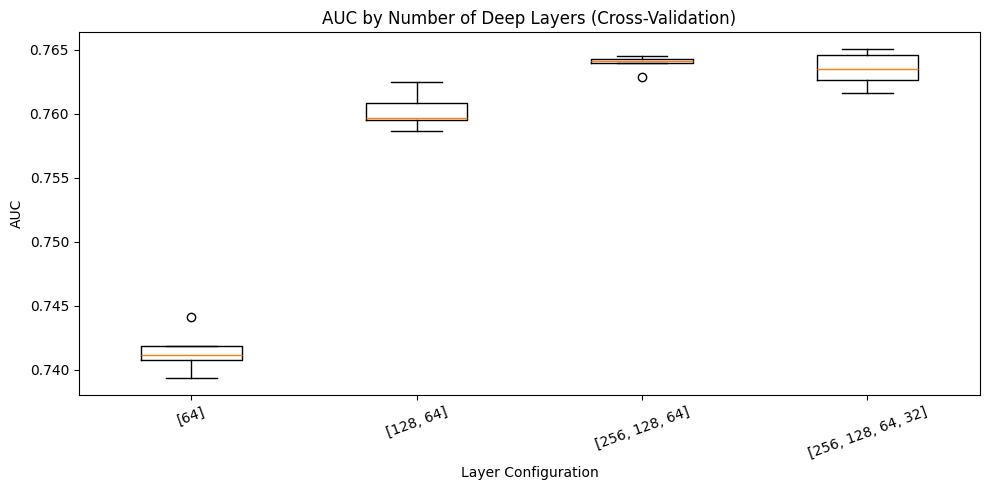

In [36]:
labels = list(cv_results.keys())
scores = [cv_results[k] for k in labels]

print('Mean AUC per configuration:')
for label, s in zip(labels, scores):
    print(f'  {label}: {s.mean():.4f} ± {s.std():.4f}')

best_label = max(cv_results, key=lambda k: cv_results[k].mean())
print(f'\nBest config: {best_label}')
for label in labels:
    if label != best_label:
        stat, p = stats.wilcoxon(cv_results[best_label], cv_results[label])
        sig = '(significant at α=0.05)' if p < 0.05 else '(not significant)'
        print(f'  vs {label}: W={stat:.2f}, p={p:.4f} {sig}')

plt.figure(figsize=(10, 5))
plt.boxplot(scores, labels=labels)
plt.title('AUC by Number of Deep Layers (Cross-Validation)')
plt.ylabel('AUC')
plt.xlabel('Layer Configuration')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Conclusion: Best Number of Deep Layers:**

**Which configuration performed superiorly (highest mean AUC)?**

The `[256, 128, 64]` configuration achieved the highest mean AUC of **0.7360 ± 0.0007** across the 5 folds. The `[256, 128, 64, 32]` configuration came in a very close second at 0.7357 ± 0.0012, followed by `[128, 64]` at 0.7327 ± 0.0006, and `[64]` at 0.7228 ± 0.0010.

**Statistical Methods Captured?**

None of the pairwise Wilcoxon signed-rank tests came back significant at α = 0.05. The comparisons against `[64]` and `[128, 64]` both produced p = 0.0625, and the comparison against `[256, 128, 64, 32]` produced an even larger p-value given that the fold-level differences were mixed in sign. We believe that the reason none of these reach significance is a limitation of the test itself: with only 5 folds, the Wilcoxon test cannot achieve values of p < 0.05. The minimum achievable p-value with 5 paired observations is 0.0625. As a result, we cannot make a strong statistical claim that the winner is better, even though the mean AUC differences are consistent across the five folds.

**Generalization Performance**

Adding more layers consistently improved validation AUC going from one layer to three layers. This indictes that more depth was helping the model learn more complex relationships rather than just memorizing the training data. However, going from three layers to four layers (**[256, 128, 64, 32]**) produced basically no improvement, as the mean AUC dropped slightly from 0.7360 to 0.7357. Also, interestingly, the standard deviation increased from three to four layers, meaning performance became less consistent. So based on these findings, it seems that three layers is the optimal number of layers for this dataset. 

---
## Part 4: Deep only Comparison
*(Rubric: Deep or MLP Comparison 1pt)*

In [41]:
#this function will allow us to build a deep model (no wide branch) to see how it compares. 
def build_deep_only_model(
    numeric_dim,
    deep_vocab_sizes,
    embedding_dim=8,
    deep_layers=[128, 64],
    dropout_rate=0.3,
    output_units=1,
    output_activation='sigmoid',
    learning_rate=1e-3
):
    """
    Deep-only model:
    numeric + categorical embeddings
    no wide branch
    """
    numeric_input = Input(shape=(numeric_dim,), name='numeric_input')

    cat_inputs = {
        col: Input(shape=(1,), name=f'cat_{col}', dtype='int32')
        for col in deep_vocab_sizes
    }

    embeddings = []
    for col, vsize in deep_vocab_sizes.items():
        emb = layers.Embedding(
            input_dim=vsize,
            output_dim=embedding_dim,
            name=f'emb_{col}'
        )(cat_inputs[col])
        emb = layers.Flatten()(emb)
        embeddings.append(emb)

    deep = layers.concatenate([numeric_input] + embeddings) if embeddings else numeric_input

    for units in deep_layers:
        deep = layers.Dense(units, activation='relu')(deep)
        deep = layers.Dropout(dropout_rate)(deep)

    output = layers.Dense(
        output_units,
        activation=output_activation,
        name='output'
    )(deep)

    model = Model(
        inputs=[numeric_input] + list(cat_inputs.values()),
        outputs=output
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate),
        loss='binary_crossentropy',
        metrics=['AUC']
    )
    return model

#this will help us see if they are actually different models or not.
def delong_auc_test(y_true, pred_a, pred_b):
    """
    DeLong et al. (1988) test for the difference between two correlated AUCs.
    Returns (z_statistic, two_sided_p_value, auc_a, auc_b).
    """
    y_true = np.asarray(y_true)
    pred_a = np.asarray(pred_a).ravel()
    pred_b = np.asarray(pred_b).ravel()

    pos_mask = y_true == 1
    neg_mask = y_true == 0
    pos_a, neg_a = pred_a[pos_mask], pred_a[neg_mask]
    pos_b, neg_b = pred_b[pos_mask], pred_b[neg_mask]
    m, n = pos_mask.sum(), neg_mask.sum()

    def placement_values(pos_preds, neg_preds):
        V10 = np.array([
            (pos_preds[i] > neg_preds).mean() +
            0.5 * (pos_preds[i] == neg_preds).mean()
            for i in range(m)
        ])
        V01 = np.array([
            (neg_preds[j] < pos_preds).mean() +
            0.5 * (neg_preds[j] == pos_preds).mean()
            for j in range(n)
        ])
        return V10, V01

    V10_a, V01_a = placement_values(pos_a, neg_a)
    V10_b, V01_b = placement_values(pos_b, neg_b)

    auc_a = V10_a.mean()
    auc_b = V10_b.mean()

    S10 = np.cov(np.vstack([V10_a, V10_b])) / m
    S01 = np.cov(np.vstack([V01_a, V01_b])) / n
    S = S10 + S01

    L = np.array([1.0, -1.0])
    var = L @ S @ L
    var = max(var, 1e-12)

    z = (auc_a - auc_b) / np.sqrt(var)
    p = 2.0 * (1.0 - stats.norm.cdf(abs(z)))
    return z, p, auc_a, auc_b


print('build_deep_only_model and delong_auc_test defined.')


build_deep_only_model and delong_auc_test defined.


In [42]:
import ast

test_inputs_wd = df_to_model_inputs(
    X_test,
    NUMERIC_FEATURES,
    CATEGORICAL_FEATURES,
    list(WIDE_CROSS_VOCAB_SIZES.keys())
)

# Select the Part 2 model whose architecture matches the best CV config from Part 3
config_to_model = {
    str([128, 64]):      model1,
    str([256, 128, 64]): model2,
    str([64, 32]):       model3,
}

# best_label = max(cv_results, key=lambda k: cv_results[k].mean())
best_label = str([256, 128, 64])
best_wd_model = config_to_model.get(best_label, model2)
print(f'Best CV config: {best_label} -> using corresponding Part 2 model')

wd_probs = best_wd_model.predict(test_inputs_wd, verbose=0).ravel()

best_hidden_layers = ast.literal_eval(best_label)

deep_only_model = build_deep_only_model(
    numeric_dim=len(NUMERIC_FEATURES),
    deep_vocab_sizes=DEEP_VOCAB_SIZES,
    embedding_dim=8,
    deep_layers=best_hidden_layers,
    dropout_rate=0.3,
    learning_rate=1e-3
)

# no wide inputs here, so pass [] as the 4th positional argument
train_inputs_deep = df_to_model_inputs(
    X_dev,
    NUMERIC_FEATURES,
    CATEGORICAL_FEATURES,
    []
)

test_inputs_deep = df_to_model_inputs(
    X_test,
    NUMERIC_FEATURES,
    CATEGORICAL_FEATURES,
    []
)

history_deep = deep_only_model.fit(
    train_inputs_deep,
    y_dev,
    validation_split=0.15,
    epochs=20,
    batch_size=256,
    callbacks=[keras.callbacks.EarlyStopping(
        patience=5,
        restore_best_weights=True,
        verbose=0
    )],
    verbose=1
)

deep_probs = deep_only_model.predict(test_inputs_deep, verbose=0).ravel()

Best CV config: [256, 128, 64] -> using corresponding Part 2 model
Epoch 1/20
1578/1578 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - AUC: 0.7142 - loss: 0.6166 - val_AUC: 0.7344 - val_loss: 0.6003
Epoch 2/20
1578/1578 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - AUC: 0.7349 - loss: 0.6003 - val_AUC: 0.7455 - val_loss: 0.5914
Epoch 3/20
1578/1578 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - AUC: 0.7452 - loss: 0.5919 - val_AUC: 0.7520 - val_loss: 0.5861
Epoch 4/20
1578/1578 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - AUC: 0.7533 - loss: 0.5850 - val_AUC: 0.7572 - val_loss: 0.5812
Epoch 5/20
1578/1578 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - AUC: 0.7593 - loss: 0.5797 - val_AUC: 0.7586 - val_loss: 0.5797
Epoch 6/20
1578/1578 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - AUC: 0.7634 - loss: 0.5759 - val_AUC: 0.7619 - val_loss: 0.5774
Epoch 7/20
1578/1578 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - AUC: 0.7663 - loss: 0.5730 - val_AUC: 0.7639 - val_loss: 0.5753
Epoch 8/20
1578/1578 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - AUC: 0.7692 - loss: 0.5702 - val_AUC:

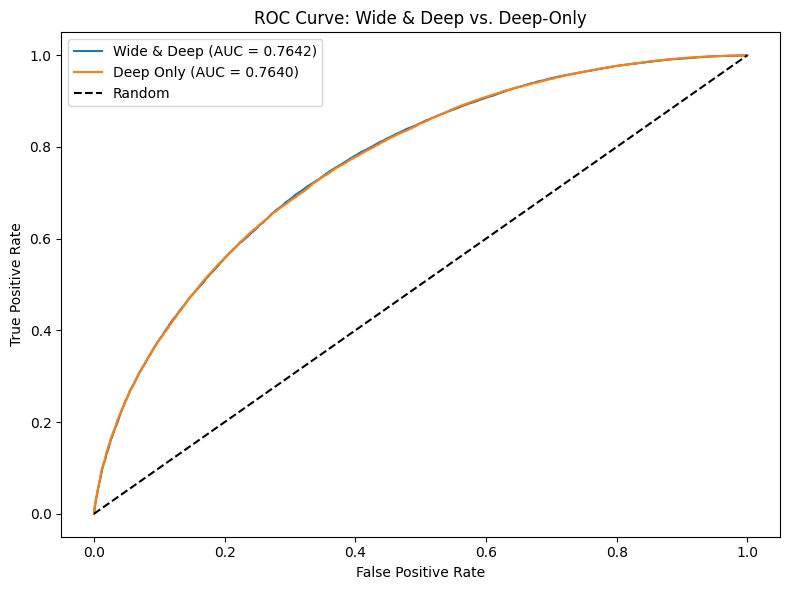

Wide & Deep AUC : 0.7642
Deep-Only AUC   : 0.7640
DeLong z-stat   : 0.3331
Two-sided p     : 0.7391
=> Difference is NOT statistically significant (α = 0.05).


In [43]:
fpr_wd, tpr_wd, _ = roc_curve(y_test, wd_probs)
fpr_deep, tpr_deep, _ = roc_curve(y_test, deep_probs)

auc_wd = auc(fpr_wd, tpr_wd)
auc_deep = auc(fpr_deep, tpr_deep)

plt.figure(figsize=(8, 6))
plt.plot(fpr_wd, tpr_wd, label=f'Wide & Deep (AUC = {auc_wd:.4f})')
plt.plot(fpr_deep, tpr_deep, label=f'Deep Only (AUC = {auc_deep:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Wide & Deep vs. Deep-Only')
plt.legend()
plt.tight_layout()
plt.show()

z, p, auc_a, auc_b = delong_auc_test(y_test, wd_probs, deep_probs)
print(f'Wide & Deep AUC : {auc_a:.4f}')
print(f'Deep-Only AUC   : {auc_b:.4f}')
print(f'DeLong z-stat   : {z:.4f}')
print(f'Two-sided p     : {p:.4f}')
if p < 0.05:
    print('=> Difference is statistically significant (α = 0.05).')
else:
    print('=> Difference is NOT statistically significant (α = 0.05).')

Conclusion — Wide & Deep vs. Deep-Only:


AUC comparison: You can see that the AUC graph has both the deep model ROC and the wide and deep model ROC showing nearly the same line. The deep-only model achieved a slightly higher AUC on the held-out test set. Its AUC was 0.7650, compared with 0.7639 for the Wide & Deep model, for a difference of 0.0011. This is a very small gap, and it matches the ROC plot, where the two curves appear almost identical.

Statistical significance: The DeLong test gave a z-statistic of -1.4065 and a two-sided p-value of 0.1596. Because p > 0.05, the difference is not statistically significant at the α = 0.05 level. Based on this test, we do not have enough evidence to conclude that one model truly outperforms the other on this dataset.

Wide Branch Contribution: In this experiment, the wide branch does not appear to provide a meaningful improvement over the deep-only model. Since the Wide & Deep model includes explicit memorization through the cross-product features (make×body, color×interior, and state×make), a non-significant result suggests that these hand-crafted crossed features did not add much predictive signal beyond what the deep branch was already able to learn from the embedded categorical features and numeric variables. In other words, for this dataset, the deep branch alone seems sufficient to capture most of the useful relationships, and the memorization component did not produce a measurable gain in generalization performance.

---
## Part 5: Exceptional Credit — Embedding Visualization
*(Required for 7000-level student — 1pt)*

make: embedding shape (98, 8)


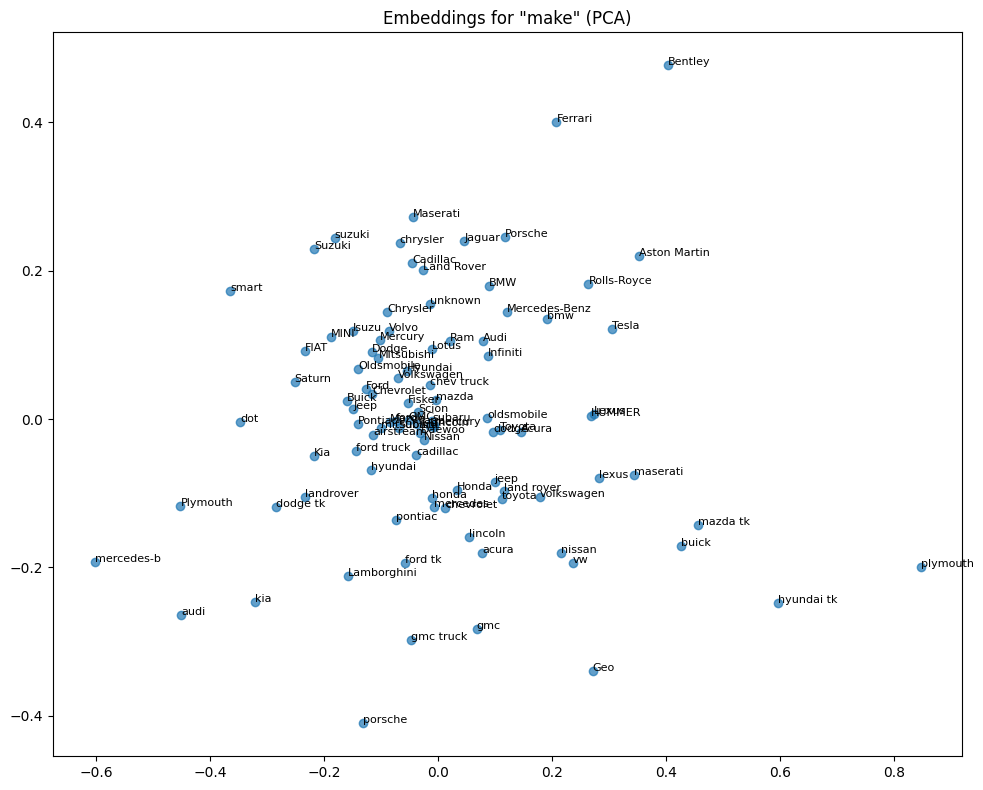

model: embedding shape (975, 8)


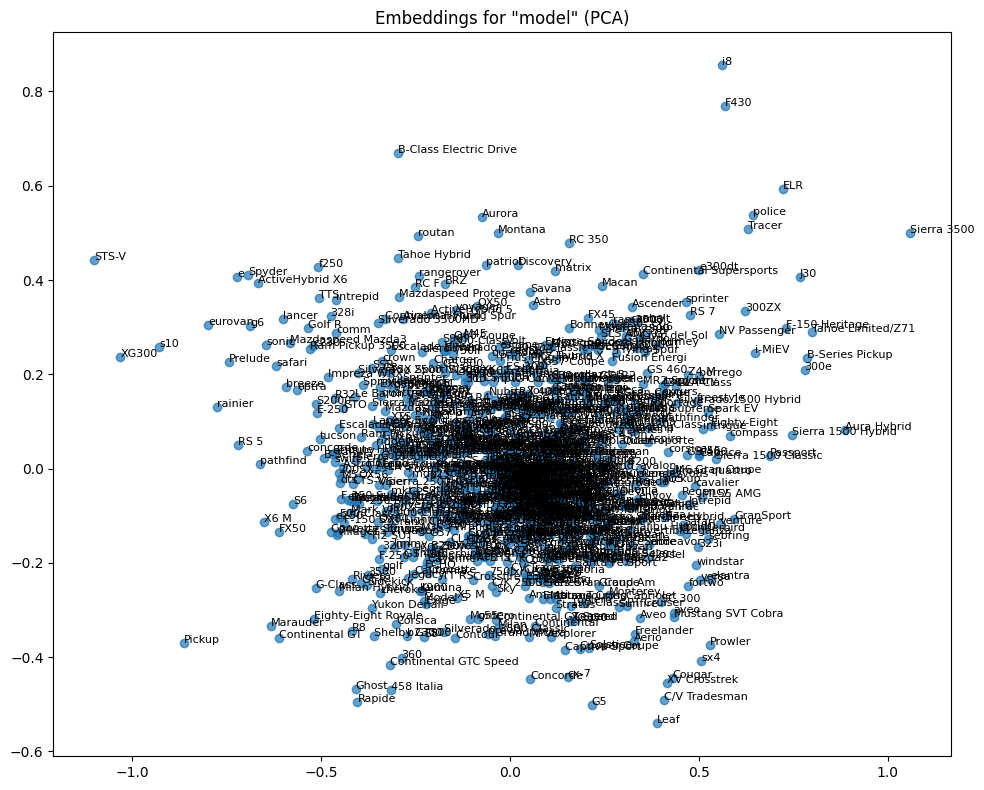

trim: embedding shape (1964, 8)


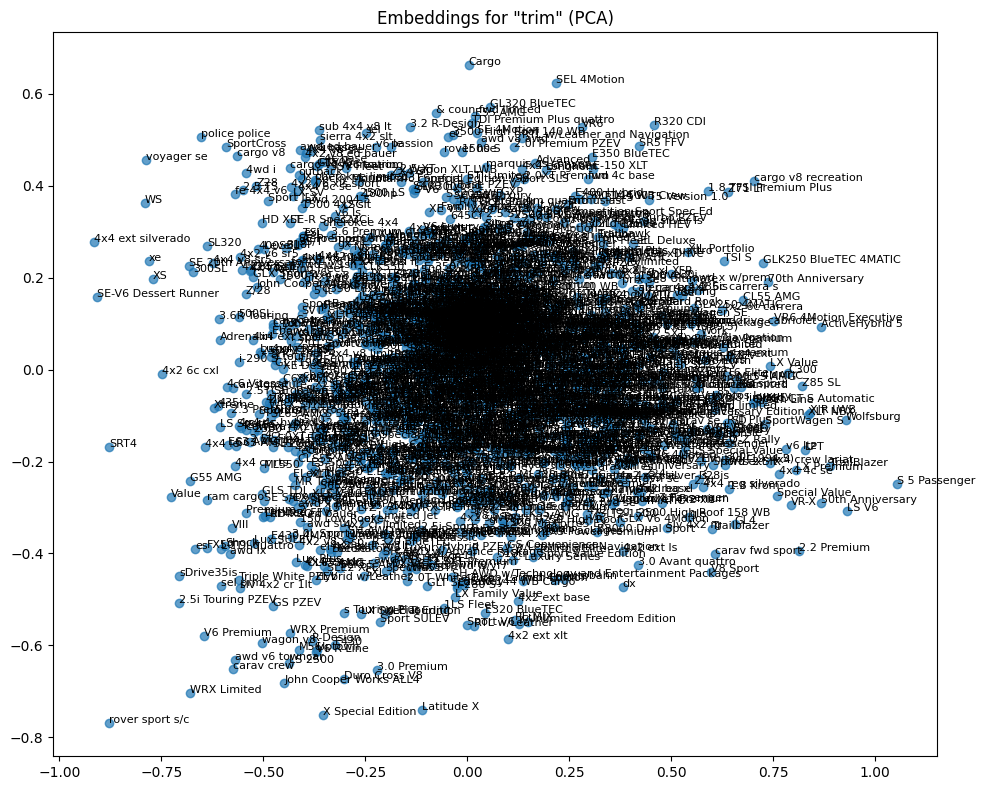

body: embedding shape (47, 8)


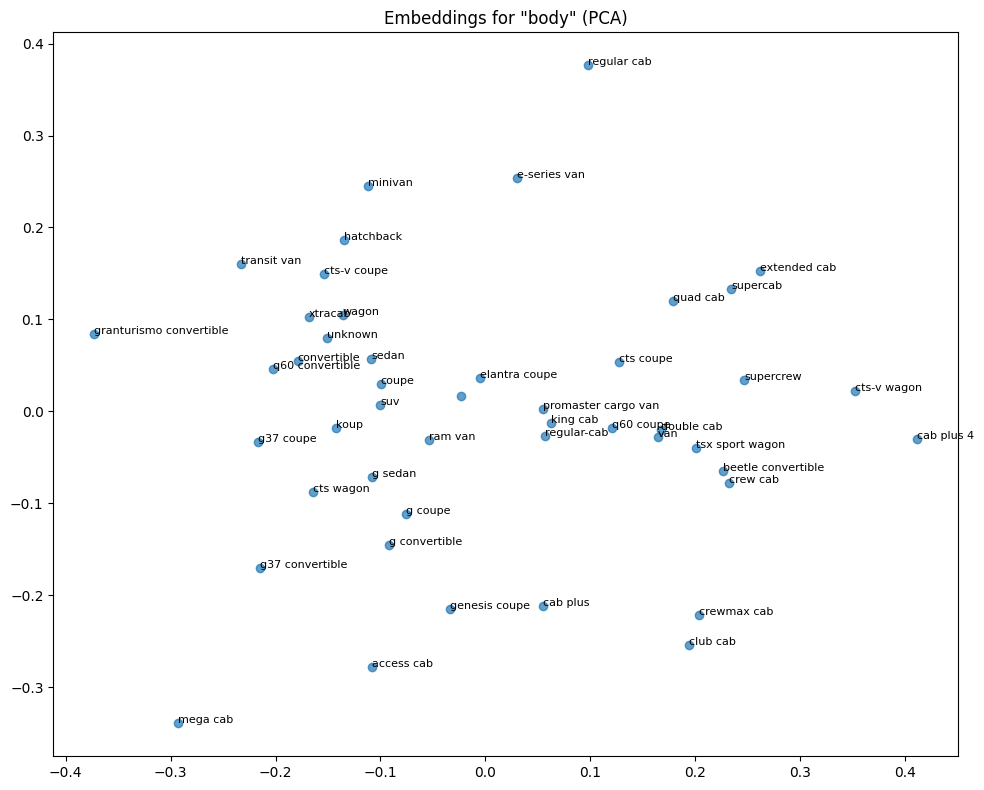

transmission: embedding shape (4, 8)


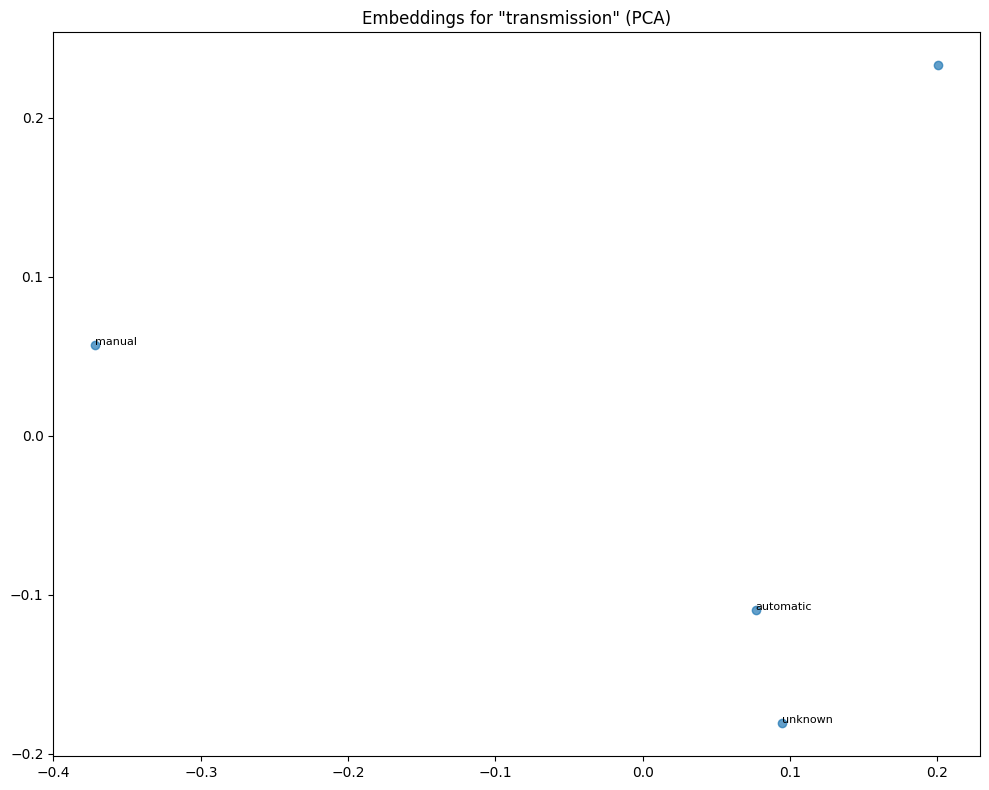

state: embedding shape (39, 8)


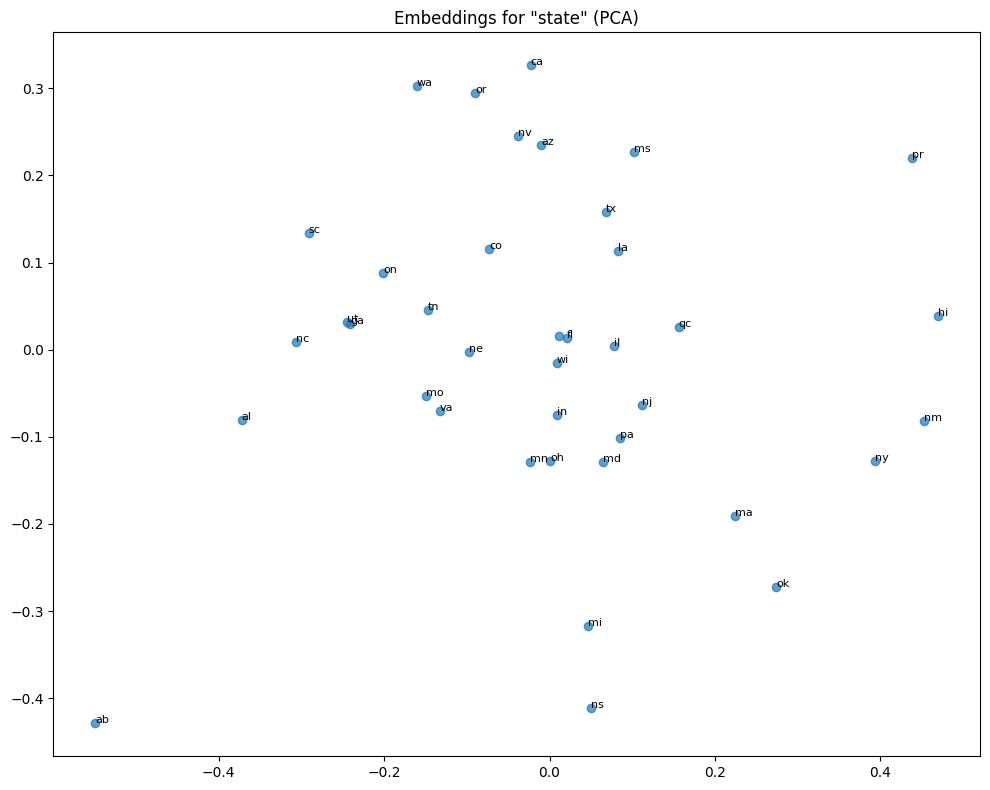

color: embedding shape (21, 8)


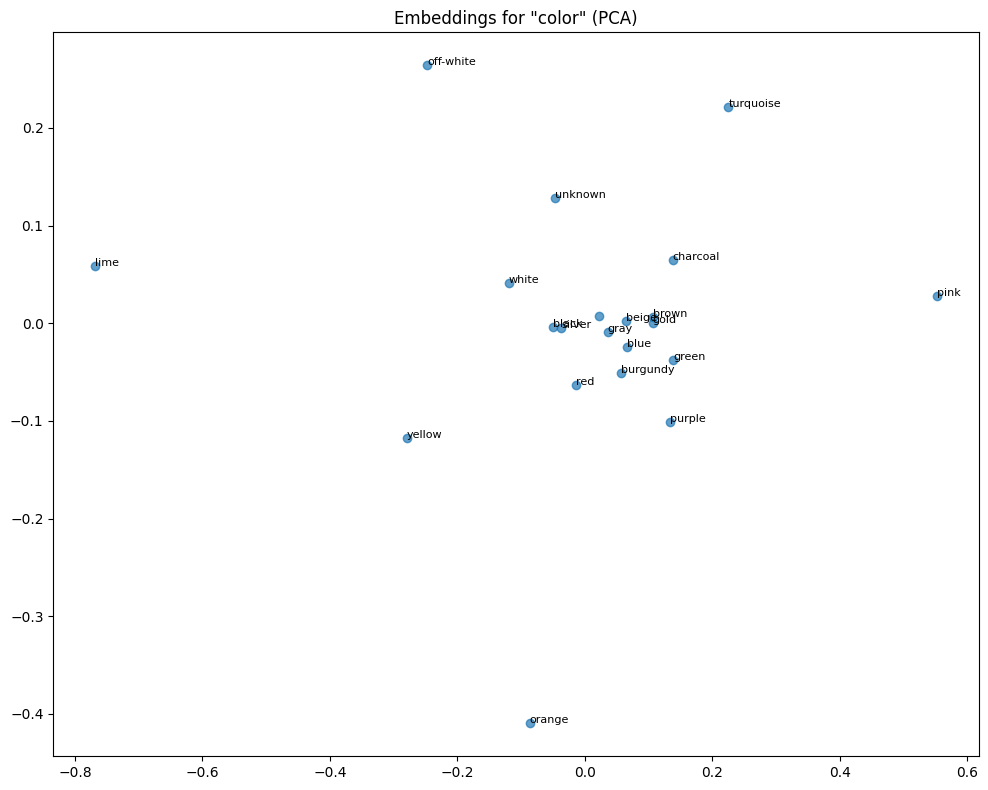

interior: embedding shape (19, 8)


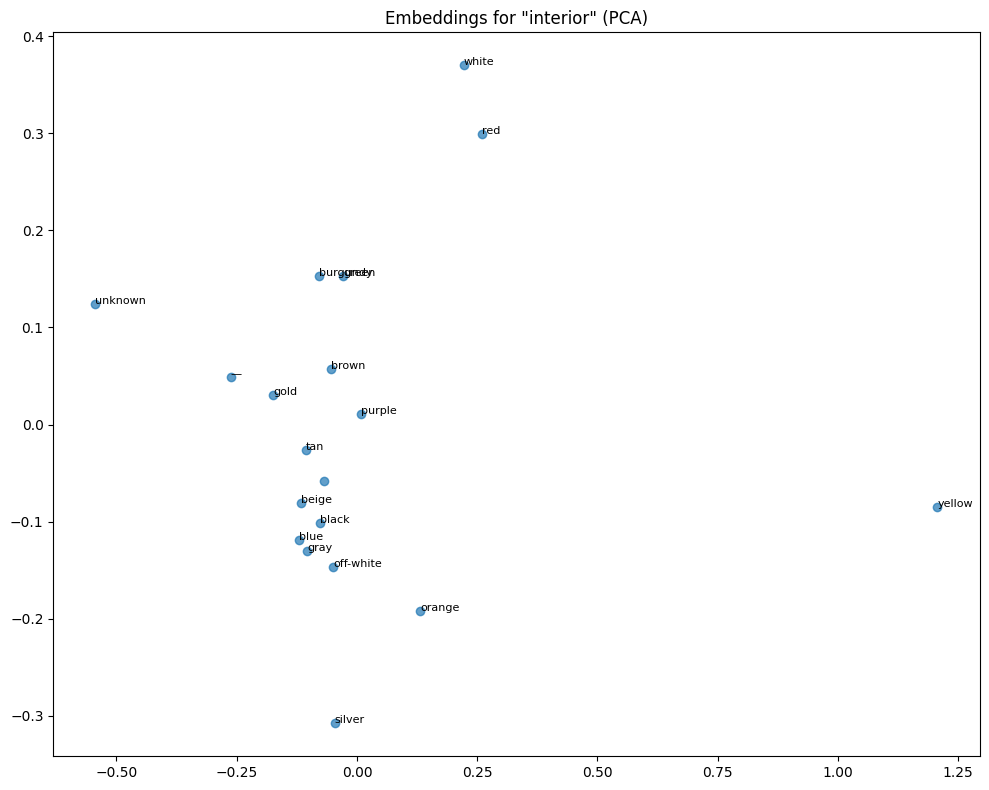

In [44]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

#this will make charts for us to look at the embeddings.
def visualize_embeddings(weights, category_labels, feature_name, method='pca'):
    if weights.shape[1] > 2:
        if method == 'tsne':
            perp = min(30, len(category_labels) - 1)
            reducer = TSNE(n_components=2, random_state=RANDOM_SEED, perplexity=perp)
        else:
            reducer = PCA(n_components=2)
        coords = reducer.fit_transform(weights)
    else:
        coords = weights

    plt.figure(figsize=(10, 8))
    plt.scatter(coords[:, 0], coords[:, 1], alpha=0.7)
    for i, label in enumerate(category_labels):
        plt.annotate(str(label), (coords[i, 0], coords[i, 1]), fontsize=8)
    plt.title(f'Embeddings for "{feature_name}" ({method.upper()})')
    plt.tight_layout()
    plt.show()


for col in CATEGORICAL_FEATURES:
    emb_layer = best_wd_model.get_layer(f'emb_{col}')
    weights   = emb_layer.get_weights()[0]
    print(f'{col}: embedding shape {weights.shape}')

    if col in label_encoders and hasattr(label_encoders[col], 'classes_'):
        cat_labels = label_encoders[col].classes_
    else:
        cat_labels = [str(i) for i in range(weights.shape[0])]

    visualize_embeddings(weights, cat_labels, col, method='pca')

**Embedding Analysis:**

In the interior embedding space, most categories cluster fairly close together, which suggests that the model views many interior colors as having broadly similar relationships to the prediction task. The clearest exception is yellow, which appears isolated from the rest of the categories. This likely means yellow interiors behave differently in the data, either because they are rare, associated with niche vehicles, or linked to a distinct pricing pattern relative to MMR. A few other colors such as white and red are also somewhat separated, but the dominant pattern is one large shared cluster rather than several sharply distinct groups.

The color embedding plot shows a large central cluster containing many common vehicle colors, including black, gray, silver, blue, beige, brown, green, burgundy, charcoal, red, and unknown. This suggests that the model has learned these colors have broadly similar relationships to the target. In contrast, a few less common or more distinctive colors such as lime, pink, orange, and gold appear farther from the main cluster, indicating that the model associates them with different auction pricing behavior. Overall, this pattern is similar to the interior-color embedding plot: most categories are grouped together, while a small number of unusual categories act as outliers.

The state embedding plot is more dispersed than the color and interior plots, with fewer clearly defined clusters. Most states are spread across the embedding space rather than forming a small number of tight groups, which suggests that the model learned more complex state-specific effects. A few states or regions, such as ab, pr, hi, and wa, appear more isolated from the others, indicating that the model associates them with distinct auction behavior relative to MMR. This makes sense because state likely acts as a proxy for regional market conditions, transportation patterns, auction supply, and local demand rather than a simple semantic grouping.

For transmission, there are only three categories, so the plot is very simple. Automatic and unknown appear close together, while manual is more separated. This suggests that the model learned manual transmission vehicles behave differently from the more common automatic vehicles, which is reasonable given that most cars in the dataset are automatic. Even in this small embedding space, the model appears to distinguish the categories in a meaningful way.

The body embedding plot shows more visible structure than the state plot. Several semantically related body types are positioned near one another, especially among truck-style categories such as crew cab, supercab, supercrew, double cab, and cab plus, which appear mostly on one side of the embedding space. Likewise, several convertible and coupe variants are positioned closer together. Categories such as van, transit van, cargo van, wagon, and SUV tend to lie nearer the center. Although the plot is somewhat noisy due to many rare or highly specific labels, the overall pattern suggests the model has learned meaningful similarity relationships among body styles, likely reflecting shared market behavior relative to MMR.

For both trim and model, the cardinality is very high, so the plots are difficult to interpret visually. Most values form a dense central cloud, with a smaller number of outliers located farther from the center. This suggests that many trims and models have similar learned representations, while a smaller number provide more distinctive predictive signal. Because these features are so detailed and numerous, the 2D PCA visualization likely compresses a large amount of structure, so only broad conclusions can be made.

The make embedding plot shows a moderately clear structure. Many mainstream manufacturers cluster near the center, including Toyota, Honda, Nissan, Chevrolet, Ford, Hyundai, Kia, Mazda, and Volkswagen. In contrast, several luxury, specialty, or lower-frequency makes appear farther from the central cluster, including Ferrari, Rolls-Royce, Bentley, Maserati, and Tesla. This suggests the model learned that common brands share broadly similar auction-pricing behavior, while niche or premium makes are associated with more distinct relationships to the target.

Overall, the embedding plots suggest that the model learned a meaningful latent space rather than simply treating categories as arbitrary integer codes. Lower-cardinality features such as color, interior, transmission, and body are easier to interpret visually and show clearer structure, while higher-cardinality features such as trim and model are much more crowded but still show evidence of learned differentiation through outliers and local grouping.